In [16]:
from __future__ import division
from __future__ import print_function
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.18.1
#   kernelspec:
#     display_name: Python 2
#     language: python
#     name: python2
# ---

import warnings
warnings.filterwarnings("ignore")

<h1>MIMIC Treatment Disparities, Stratified by Mistrust</h1>
The code can stand to be cleaned up to mirror the tidy-ness of race_mimic_aggressive.ipynb, but it generates the figures from the poster.

In [2]:
from __future__ import absolute_import
from future import standard_library
from six.moves import map
from six.moves import range
from six.moves import zip
standard_library.install_aliases()
from builtins import zip
from builtins import map
from builtins import str
from builtins import range
from past.utils import old_div
import psycopg2
import tqdm

# create a database connection
sqluser = 'wboag'
dbname = 'mimic'
schema_name = 'mimiciii'

# Connect to the database
# con = psycopg2.connect(dbname=dbname, user=sqluser, host="/var/run/postgresql")
con = psycopg2.connect(dbname=dbname, user=sqluser, host="host.docker.internal", port="5432")

In [3]:
# Preprocessing / Normalization

def normalize_race(race):
    if 'HISPANIC' in race:
        return 'Hispanic'
    if 'SOUTH AMERICAN' in race:
        return 'Hispanic'
    if 'AMERICAN INDIAN' in race:
        return 'Native American'
    if 'ASIAN' in race:
        return 'Asian'
    if 'BLACK' in race:
        return 'Black'
    if 'WHITE' in race:
        return 'White'
    return 'Other'

def normalize_discharge(disch):
    if disch.startswith('HOSPICE'):
        return 'Hospice'
    if disch == 'DEAD/EXPIRED':
        return 'Deceased'
    if disch.startswith('SNF'):
        return 'Skilled Nursing Facility'
    return 'other'

In [4]:
# Query for data

import pandas as pd
import time

print(time.strftime("%Y-%m-%d %H:%M:%s"))

# static demographic info 
# [repro] note: 
# - updated `age` to `admission_age`
# - filtered to first ICU stay only to match original behavior
demographics_query = 'SELECT distinct subject_id,hadm_id,gender,ethnicity,admission_age as age FROM mimiciii.icustay_detail WHERE first_icu_stay = True;' 
demographics = pd.read_sql_query(demographics_query, con)

demographics['ethnicity'] = demographics['ethnicity'].apply(normalize_race)
demographics = demographics.rename(columns={'ethnicity':'race'})

def normalize_age(age):
    return min(age, 90)
demographics['age'] = demographics['age'].apply(normalize_age)


# admissions info
discharge_query = '''SELECT distinct subject_id,hadm_id,ethnicity,discharge_location,admittime,dischtime
  FROM mimiciii.admissions;'''
discharge = pd.read_sql_query(discharge_query, con)

discharge['discharge_location'] = discharge['discharge_location'].apply(normalize_discharge)

discharge['ethnicity'] = discharge['ethnicity'].apply(normalize_race)
discharge = discharge.rename(columns={'ethnicity':'race'})

print(time.strftime("%Y-%m-%d %H:%M:%s"))

discharge.head()

2025-12-02 20:49:1764708592
2025-12-02 20:49:1764708593


,subject_id,hadm_id,race,discharge_location,admittime,dischtime
0,31029,184132,Black,other,2106-01-14 21:00:00,2106-01-18 17:01:00
1,16068,151387,Other,other,2126-10-02 17:24:00,2126-10-09 15:50:00
2,29752,111611,White,other,2146-09-28 07:21:00,2146-10-01 14:45:00
3,27136,176216,Other,Deceased,2159-09-03 02:35:00,2159-09-04 14:09:00
4,11384,140409,White,other,2135-01-19 17:47:00,2135-01-26 12:00:00


In [5]:
# EOL Cohort
import numpy as np

print(time.strftime("%Y-%m-%d %H:%M:%s"))

# query for discharge info
mortality_query = 'SELECT distinct subject_id,dod FROM mimiciii.patients'
mortality = pd.read_sql_query(mortality_query, con)

# patients who died or went to hospice
#eol_locations = {'Hospice', 'Deceased'}
eol_locations = {'Hospice', 'Deceased', 'Skilled Nursing Facility'}
disch = discharge.loc[discharge['discharge_location'].isin(eol_locations)]

expired = pd.merge(discharge,mortality, on=['subject_id'])
expired['mort'] = expired['dod'] - expired['dischtime']
six_months = expired.loc[expired['mort']<=pd.Timedelta(days=360)]
in_hosp = expired.loc[expired['mort']<=pd.Timedelta(days=0)]
zero_to_six = six_months.loc[~six_months['hadm_id'].isin(in_hosp)]
one_week = expired.loc[expired['mort']<=pd.Timedelta(days=7)]

#ids =  set(six_months.hadm_id.values) | set(disch)
#ids =  set(six_months.hadm_id.values) | set(disch)
#ids =  (set(six_months.hadm_id.values) & set(disch))
#ids =  set(six_months.hadm_id.values) 
#ids =  set(in_hosp.hadm_id.values) | set(disch.hadm_id.values)
ids =  set(disch.hadm_id.values)
#ids =  set(zero_to_six.hadm_id.values) 
#ids =  set(one_week.hadm_id.values) 
#ids =  (set(zero_to_six.hadm_id.values)) & set(disch.hadm_id.values)
#ids =  (set(zero_to_six.hadm_id.values)) & set(disch.hadm_id.values)
#ids =  (set(zero_to_six.hadm_id.values))
#ids =  set(disch.hadm_id.values)
#ids =  set(disch.hadm_id.values) & set(six_months.hadm_id.values)
#eol_cohort_initial = six_months
eol_cohort_initial = discharge.loc[discharge.hadm_id.isin(ids)]

inds_at_least_6hrs = eol_cohort_initial['dischtime'] - eol_cohort_initial['admittime'] > pd.Timedelta(days=1)
eol_cohort_initial = eol_cohort_initial.loc[inds_at_least_6hrs]

# add demographics info
eol_cohort = pd.merge(eol_cohort_initial, demographics, on=['hadm_id','race'])
#eol_cohort = eol_cohort.rename(columns={'ethnicity':'race'})

# normalize columns of data
#eol_cohort['discharge_location'] = eol_cohort['discharge_location'].apply(normalize_discharge)


# make sure each hadm_id has only died once
print('eol subjects:', len(eol_cohort))
print('eol subjects:', len(set(eol_cohort['hadm_id'].values)))
assert len(eol_cohort) == len(set(eol_cohort['hadm_id'].values))

print(time.strftime("%Y-%m-%d %H:%M:%s"))

2025-12-02 20:49:1764708593
eol subjects: 12892
eol subjects: 12892
2025-12-02 20:49:1764708593


In [6]:
# Useful processing tools for treatment duration data

from collections import defaultdict

def find(groups, it):
    for i,group in enumerate(groups):
        if it in group:
            return i

def transitive_closure(items, merge):
    groups = [ [it] for it in items ]
    for a,b in merge:
        # make sure a and b are in the same group
        group_a = find(groups, a)
        group_b = find(groups, b)
        if group_a < group_b:
            group_ab = groups[group_a] + groups[group_b]
            del groups[group_b]
            del groups[group_a]
            groups.append(group_ab)
        elif group_a > group_b:
            group_ab = groups[group_a] + groups[group_b]
            del groups[group_a]
            del groups[group_b]
            groups.append(group_ab)
        else:
            # already same group
            pass
    return groups

In [7]:
# Mechanical Ventilation

import tqdm

eol_hadmids = list(map(str,set(eol_cohort['hadm_id'].values)))

# [repro] updated `ventdurations` to use ventilation_durations table
query = \
"""
select i.hadm_id, v.starttime, v.endtime
FROM mimiciii.icustay_detail i
INNER JOIN mimiciii.ventilation_durations v ON i.icustay_id = v.icustay_id
where i.hadm_id in (%s)
and v.starttime between intime and outtime
and v.endtime between intime and outtime;
""" % ','.join(eol_hadmids)

vent_data = pd.read_sql_query(query, con)


duration_aggregate = 'sum_spans'
vent_spans = defaultdict(list)
for hadm_id,rows in tqdm.tqdm(vent_data.groupby('hadm_id')):
    rows =  rows.sort_values('starttime')
    
    if duration_aggregate == 'max-min':
        span = rows.iloc[-1].endtime - rows.iloc[0].starttime
        assert span > pd.Timedelta(days=0)
        vent_spans[hadm_id].append(span)   
    elif duration_aggregate == 'sum_spans':
        merge = []
        for i in range(len(rows)-1):
            if rows.iloc[i+1].starttime - rows.iloc[i].endtime <= pd.Timedelta(hours=10):
                merge.append( (i,i+1) )

        for group in transitive_closure(list(range(len(rows))), merge):
            lo = min(group)
            hi = max(group)
            span = rows.iloc[hi].endtime - rows.iloc[lo].starttime
            assert span > pd.Timedelta(days=0)
            vent_spans[hadm_id].append(span)
    else:
        raise Exception('dunno!')

vent_quantity = { hadm_id:sum([ts.total_seconds()/60. for ts in timestamps]) for hadm_id,timestamps in list(vent_spans.items()) }
#vent_quantity = { hadm_id:timestamps[0].total_seconds()/60. for hadm_id,timestamps in vent_spans.items() }
#vent_quantity = { hadm_id:timestamps[-1].total_seconds()/60. for hadm_id,timestamps in vent_spans.items() }

100%|██████████| 6302/6302 [00:02<00:00, 2332.53it/s]


In [8]:
# Vasopressors

import tqdm

# [repro] updated `vasopressordurations` to use vasopressor_durations table
# Start merging all other interventions
table_names  = ['vasopressor_durations']
column_names = ['vaso'                ]

eol_hadmids = list(map(str,set(eol_cohort['hadm_id'].values)))

vaso_quantities = defaultdict(dict)
for t, c in zip(table_names, column_names):
    print((t, c))
    # TOTAL VASOPRESSOR DATA
    query = """
    select i.hadm_id, v.starttime, v.endtime
    FROM mimiciii.icustay_detail i
    INNER JOIN mimiciii.%s v ON i.icustay_id = v.icustay_id
    where v.starttime between intime and outtime
    and   v.endtime   between intime and outtime
    and i.hadm_id in (%s);
    """ % (t, ','.join(eol_hadmids))
    vaso_data = pd.read_sql_query(query,con)
    print (vaso_data.head())

    #print time.strftime("%Y-%m-%d %H:%M:%s")

    duration_aggregate = 'sum_spans'
    vaso_spans = defaultdict(list)
    for hadm_id,rows in tqdm.tqdm(vaso_data.groupby('hadm_id')):
        rows =  rows.sort_values('starttime')

        if duration_aggregate == 'max-min':
            span = rows.iloc[-1].endtime - rows.iloc[0].starttime
            assert span >= pd.Timedelta(days=0)
            vaso_spans[hadm_id].append(span)   
        elif duration_aggregate == 'sum_spans':
            merge = []
            for i in range(len(rows)-1):
                if rows.iloc[i+1].starttime - rows.iloc[i].endtime <= pd.Timedelta(hours=10):
                    merge.append( (i,i+1) )

            for group in transitive_closure(list(range(len(rows))), merge):
                lo = min(group)
                hi = max(group)
                span = rows.iloc[hi].endtime - rows.iloc[lo].starttime
                assert span >= pd.Timedelta(days=0)
                vaso_spans[hadm_id].append(span)
        else:
            raise Exception('dunno!')
            
    vaso_quantities[c] = { hadm_id:sum([ts.total_seconds()/60. for ts in timestamps]) for hadm_id,timestamps in list(vaso_spans.items()) }
    #vaso_quantities[c] = { hadm_id:timestamps[0].total_seconds()/60. + 5 for hadm_id,timestamps in vaso_spans.items() }
    #vaso_quantities[c] = { hadm_id:timestamps[-1].total_seconds()/60. for hadm_id,timestamps in vaso_spans.items() }



('vasopressor_durations', 'vaso')
   hadm_id           starttime             endtime
0   179633 2127-03-03 16:15:00 2127-03-03 20:35:00
1   165426 2150-11-13 15:00:00 2150-11-15 08:00:00
2   198650 2198-08-10 18:30:00 2198-08-10 19:45:00
3   198650 2198-08-10 19:57:00 2198-08-10 20:32:00
4   198650 2198-08-10 20:50:00 2198-08-11 01:30:00


100%|██████████| 5802/5802 [00:03<00:00, 1692.08it/s]


In [9]:
# load oasis severity scores
oasis_query = 'select hadm_id,max(oasis) as oasis from mimiciii.oasis group by hadm_id'
oasis_df = pd.read_sql_query(oasis_query, con)
severities = dict(oasis_df[['hadm_id','oasis']].values)
print(len(severities))

57786


<h1>Racial Disparities in Mistrust Metrics</h1>

2025-12-02 20:50:1764708656
2025-12-02 20:50:1764708656
	white:    9449 0.13144364103896503
	black: 1148 0.14842958512820226
	p-value: 0.17311590812462208


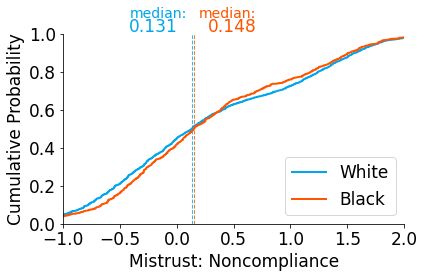

In [17]:
import pylab as pl
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu

# Mistrust scores
print(time.strftime("%Y-%m-%d %H:%M:%s"))
import pickle as pickle
with open('../data/mistrust_noncompliant.pkl', 'rb') as f:
    scores = pickle.load(f)
vals = np.array(list(scores.values()))
mu = vals.mean()
std = vals.std()
scores = {hadm_id:old_div((s-mu),std) for hadm_id,s in list(scores.items())}
print(time.strftime("%Y-%m-%d %H:%M:%s"))

# Get b/w cohorts
white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(scores.keys())
black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(scores.keys())
#white_ids = set(demographics.loc[demographics['race']=='White'].hadm_id.values) & set(scores.keys())
#black_ids = set(demographics.loc[demographics['race']=='Black'].hadm_id.values) & set(scores.keys())

white_mistrust = [scores[hadm_id] for hadm_id in white_ids]
black_mistrust = [scores[hadm_id] for hadm_id in black_ids]


def list_median(vals):
    svals = sorted(vals)
    return svals[old_div(len(svals),2)]

def captialize(t):
    return ' '.join([w.capitalize() for w in t.split()])

colors = ['#00A6ED', '#FF5400']
i = 0

fig = pl.figure()

w_median = list_median(white_mistrust)
b_median = list_median(black_mistrust)
larger_median = max(w_median, b_median)

mistrusts = {'White':white_mistrust, 'Black':black_mistrust}

for demographic in ['White', 'Black']:
    vals = list(mistrusts[demographic])
    #print(len(vals))
    #print (np.sort(vals)[int(len(vals)/2)])
    pl.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[i], label = demographic, lw=2)
    pl.xlim((-1,2))
    pl.ylim((0,1.0))

    median = np.sort(vals)[int(old_div(len(vals),2))]
    pl.axvline(x=median, linestyle="--", lw=1, color=colors[i], alpha=0.8) 
    p = 0.55
    if median == larger_median:
        h = 'right'
    else:
        p = -p
        h = 'left'
    #h = 'center'
    pl.text(x=median+p, y=1.085, horizontalalignment=h, s="median:", fontsize=14, color=colors[i])
    pl.text(x=median+p, y=1.01 , horizontalalignment=h, s=('%.3f' % median), fontsize=17, color=colors[i])

    i += 1

ax = plt.subplot(111)    
ax.spines["top"].set_visible(False)    
#ax.spines["bottom"].set_visible(False)    
ax.spines["right"].set_visible(False)    
#ax.spines["left"].set_visible(False)    
pl.yticks(fontsize=17)    
pl.xticks(fontsize=17) 

pl.legend(loc=4, fontsize=17)
pl.ylabel("Cumulative Probability", fontsize=17)
pl.xlabel("Mistrust: Noncompliance", fontsize=17)

pl.tight_layout()
pl.savefig('../images/chapter4/mistrust_noncompliant_mimic.png')

p1 = list(white_mistrust)
p2 = list(black_mistrust)
w = mannwhitneyu(p1, p2)
print('\twhite:   ', len(p1), w_median)
print('\tblack:', len(p2), b_median)
print('\tp-value:', w.pvalue)

pl.show()

2025-12-02 20:51:1764708662
2025-12-02 20:51:1764708662
	white:    9449 -0.25510827583846224
	black: 1148 -0.3402484407616562
	p-value: 0.14369610227567992


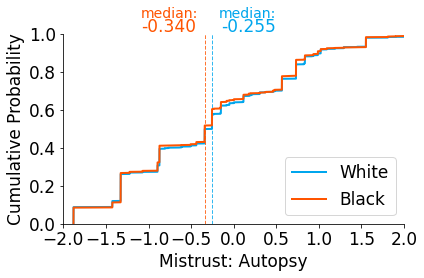

In [18]:
import pylab as pl
import numpy as np
from scipy.stats import mannwhitneyu
import random

# Mistrust scores
print(time.strftime("%Y-%m-%d %H:%M:%s"))
import pickle as pickle
with open('../data/mistrust_autopsy.pkl', 'rb') as f:
    scores = pickle.load(f)
vals = np.array(list(scores.values()))
mu = vals.mean()
std = vals.std()
scores = {hadm_id:old_div((s-mu),std) for hadm_id,s in list(scores.items())}
print(time.strftime("%Y-%m-%d %H:%M:%s"))

# Get b/w cohorts
white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(scores.keys())
black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(scores.keys())
#white_ids = set(demographics.loc[demographics['race']=='White'].hadm_id.values) & set(scores.keys())
#black_ids = set(demographics.loc[demographics['race']=='Black'].hadm_id.values) & set(scores.keys())


white_mistrust = [scores[hadm_id]+old_div(random.random(),1000) for hadm_id in white_ids]
black_mistrust = [scores[hadm_id]+old_div(random.random(),1000) for hadm_id in black_ids]


def list_median(vals):
    svals = sorted(vals)
    return svals[old_div(len(svals),2)]

def captialize(t):
    return ' '.join([w.capitalize() for w in t.split()])

colors = ['#00A6ED', '#FF5400']
i = 0

fig = pl.figure()

w_median = list_median(white_mistrust)
b_median = list_median(black_mistrust)
larger_median = max(w_median, b_median)

mistrusts = {'White':white_mistrust, 'Black':black_mistrust}

for demographic in ['White', 'Black']:
    vals = list(mistrusts[demographic])
    #print(len(vals))
    #print (np.sort(vals)[int(len(vals)/2)])
    pl.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[i], label = demographic, lw=2)
    pl.xlim((-2,2))
    pl.ylim((0,1.0))

    median = np.sort(vals)[int(old_div(len(vals),2))]
    pl.axvline(x=median, linestyle="--", lw=1, color=colors[i], alpha=0.8) 
    p = 0.75
    if median == larger_median:
        h = 'right'
    else:
        p = -p
        h = 'left'
    #h = 'center'
    pl.text(x=median+p, y=1.085, horizontalalignment=h, s="median:", fontsize=14, color=colors[i])
    pl.text(x=median+p, y=1.01 , horizontalalignment=h, s=('%.3f' % median), fontsize=17, color=colors[i])

    i += 1

ax = plt.subplot(111)    
ax.spines["top"].set_visible(False)    
#ax.spines["bottom"].set_visible(False)    
ax.spines["right"].set_visible(False)    
#ax.spines["left"].set_visible(False)    
pl.yticks(fontsize=17)    
pl.xticks(fontsize=17) 

plt.legend(loc=4, fontsize=17)
pl.ylabel("Cumulative Probability", fontsize=17)
pl.xlabel("Mistrust: Autopsy", fontsize=17)

pl.tight_layout()
pl.savefig('../images/chapter4/mistrust_autopsy_mimic.png')

p1 = list(white_mistrust)
p2 = list(black_mistrust)
w = mannwhitneyu(p1, p2)
print('\twhite:   ', len(p1), w_median)
print('\tblack:', len(p2), b_median)
print('\tp-value:', w.pvalue)

pl.show()

2025-12-02 20:51:1764708669
2025-12-02 20:51:1764708669
-0.55
0.55
	white:    9230 0.15713975693163756
	black: 1131 0.22323705626738072
	p-value: 0.0062328837798357566


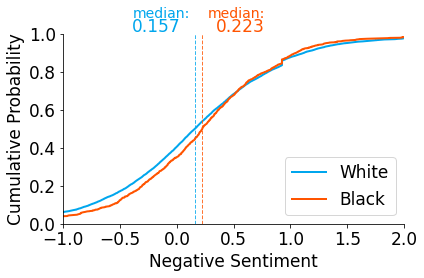

In [19]:
import pylab as pl
import numpy as np
from scipy.stats import mannwhitneyu
import random

# Mistrust scores
print(time.strftime("%Y-%m-%d %H:%M:%s"))
import pickle as pickle
with open('../data/neg_sentiment.pkl', 'rb') as f:
    scores = pickle.load(f)
vals = np.array(list(scores.values()))
mu = vals.mean()
std = vals.std()
scores = {hadm_id:old_div((s-mu),std) for hadm_id,s in list(scores.items())}
print(time.strftime("%Y-%m-%d %H:%M:%s"))

# Get b/w cohorts
white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(scores.keys())
black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(scores.keys())
#white_ids = set(demographics.loc[demographics['race']=='White'].hadm_id.values) & set(scores.keys())
#black_ids = set(demographics.loc[demographics['race']=='Black'].hadm_id.values) & set(scores.keys())

white_mistrust = [scores[hadm_id] for hadm_id in white_ids]
black_mistrust = [scores[hadm_id] for hadm_id in black_ids]


def list_median(vals):
    svals = sorted(vals)
    return svals[old_div(len(svals),2)]

def captialize(t):
    return ' '.join([w.capitalize() for w in t.split()])

colors = ['#00A6ED', '#FF5400']
i = 0

fig = pl.figure()

w_median = list_median(white_mistrust) 
b_median = list_median(black_mistrust)
larger_median = max(w_median, b_median)

mistrusts = {'White':white_mistrust, 'Black':black_mistrust}

for demographic in ['White', 'Black']:
    vals = list(mistrusts[demographic])
    #print(len(vals))
    #print (np.sort(vals)[int(len(vals)/2)])
    plt.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[i], label = demographic, lw=2)
    plt.xlim((-1,2))
    plt.ylim((0,1.0))

    median = np.sort(vals)[int(old_div(len(vals),2))]
    plt.axvline(x=median, linestyle="--", lw=1, color=colors[i], alpha=0.8) 
    p = 0.55
    if median == larger_median:
        h = 'right'
    else:
        p = -p
        h = 'left'
    #h = 'center'
    print(p)
    plt.text(x=median+p, y=1.085, horizontalalignment=h, s="median:", fontsize=14, color=colors[i])
    plt.text(x=median+p, y=1.01 , horizontalalignment=h, s=('%.3f' % median), fontsize=17, color=colors[i])

    i += 1

ax = plt.subplot(111)    
ax.spines["top"].set_visible(False)    
#ax.spines["bottom"].set_visible(False)    
ax.spines["right"].set_visible(False)    
#ax.spines["left"].set_visible(False)    
plt.yticks(fontsize=17)    
plt.xticks(fontsize=17) 

plt.legend(loc=4, fontsize=17)
plt.ylabel("Cumulative Probability", fontsize=17)
plt.xlabel("Negative Sentiment", fontsize=17)

plt.tight_layout()
plt.savefig('../images/chapter4/neg_sentiment_mimic.png')

p1 = list(white_mistrust)
p2 = list(black_mistrust)
w = mannwhitneyu(p1, p2)
print('\twhite:   ', len(p1), w_median)
print('\tblack:', len(p2), b_median)
print('\tp-value:', w.pvalue)

plt.show()

<h1>Trust-based Treatment Disparities</h1>

2025-12-02 20:51:1764708675
2025-12-02 20:51:1764708675
mistrust_noncompliant
vent
	trust:    4536 2430.0
	mistrust: 484 4590.0
	p-value: 1.0110159408972756e-13


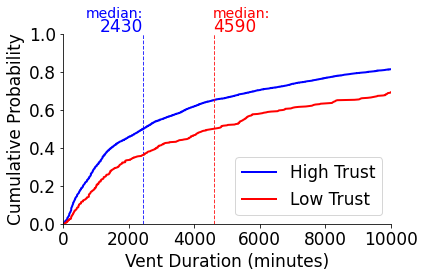

mistrust_noncompliant
vaso
	trust:    4189 1770.0
	mistrust: 421 2150.0
	p-value: 0.002741556747222445


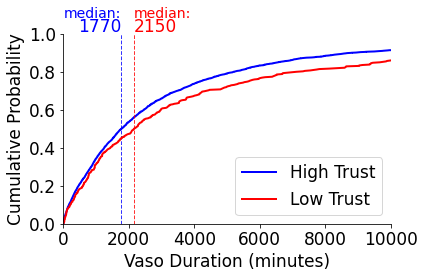

100%|██████████| 2/2 [00:00<00:00, 609.64it/s]


vent 35 43 1673 1673 1674
vaso 34 42 1536 1537 1537


100%|██████████| 2/2 [00:00<00:00, 347.80it/s]

vent
	 low
		 High Trust 1538
		 Low Trust 149
	 medium
		 High Trust 1634
		 Low Trust 185
	 high
		 High Trust 1364
		 Low Trust 150
vaso
	 low
		 High Trust 1422
		 Low Trust 132
	 medium
		 High Trust 1437
		 Low Trust 157
	 high
		 High Trust 1330
		 Low Trust 132
vent
	 vent low
		 High Trust 1538
		 Low Trust 149
vent low
	trust:    1538 1437.0
	mistrust: 149 5235.0
	p-value: 2.571328471797345e-10
	 vent medium
		 High Trust 1634
		 Low Trust 185
vent medium
	trust:    1634 2610.0
	mistrust: 185 4045.0
	p-value: 0.0004686136431853036
	 vent high
		 High Trust 1364
		 Low Trust 150
vent high
	trust:    1364 3385.0
	mistrust: 150 4830.0
	p-value: 0.0017988782988089893


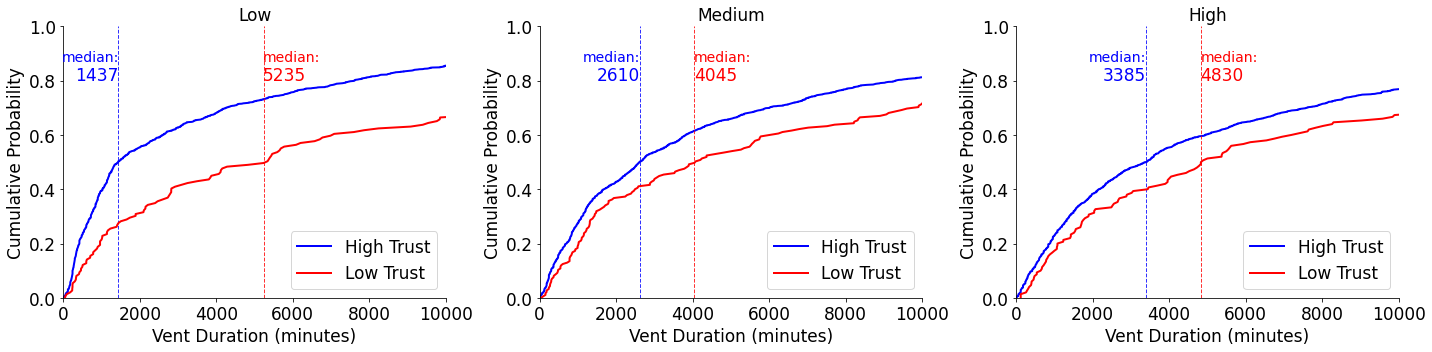

vaso
	 vaso low
		 High Trust 1422
		 Low Trust 132
vaso low
	trust:    1422 1327.0
	mistrust: 132 1800.0
	p-value: 0.004539564106563262
	 vaso medium
		 High Trust 1437
		 Low Trust 157
vaso medium
	trust:    1437 1774.0
	mistrust: 157 1740.0
	p-value: 0.2857864727413362
	 vaso high
		 High Trust 1330
		 Low Trust 132
vaso high
	trust:    1330 2255.0
	mistrust: 132 2940.0
	p-value: 0.019385255269936206


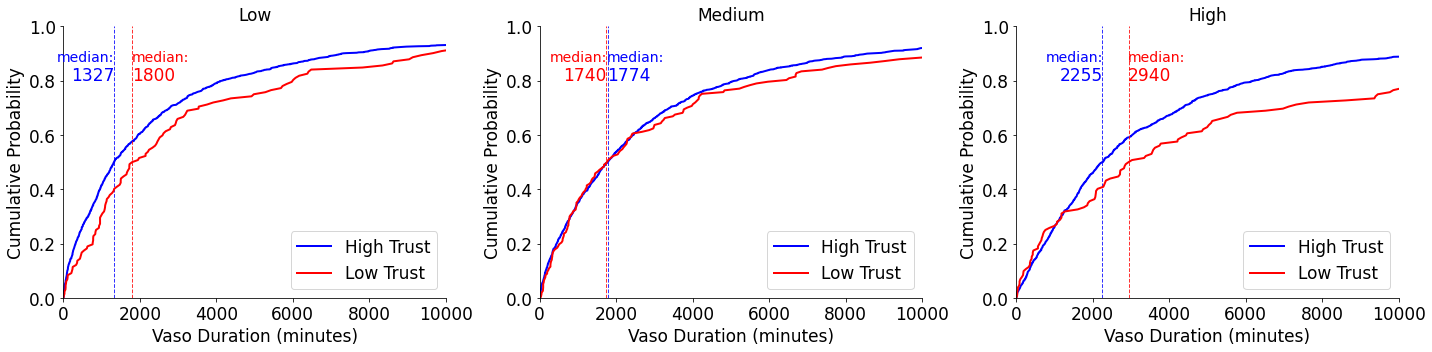

In [20]:
# Mistrust scores
print(time.strftime("%Y-%m-%d %H:%M:%s"))
import pickle as pickle

mistrust_str = 'mistrust_noncompliant'
#mistrust_str = 'mistrust_autopsy'
#mistrust_str = 'neg_sentiment'

with open('../data/%s.pkl' % mistrust_str, 'rb') as f:
    trust_scores = pickle.load(f)
print(time.strftime("%Y-%m-%d %H:%M:%s"))


%matplotlib inline

import pylab as pl
import numpy as np
from scipy.stats import mannwhitneyu


# Put each treatment into the dictionary
T = {}
for vaso,vaso_quantity in list(vaso_quantities.items()): 
    # Get size of b/w cohorts
    vaso_white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(trust_scores.keys()) & set(vaso_quantity.keys())
    vaso_black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(trust_scores.keys()) & set(vaso_quantity.keys())

    # Stratify into high/low trust
    vaso_cohort = (vaso_white_ids | vaso_black_ids)  & set(vaso_quantity.keys())
    vaso_cohort_ids = sorted([(hadm_id,trust_scores[hadm_id]) for hadm_id in vaso_cohort], key=lambda t:t[1])
    vaso_trust_ids    = [hadm_id for hadm_id,score in vaso_cohort_ids[:len(vaso_white_ids) ]]
    vaso_mistrust_ids = [hadm_id for hadm_id,score in vaso_cohort_ids[ len(vaso_white_ids):]]

    trust_eol_vaso    = {hadm_id:vaso_quantity[hadm_id] for hadm_id in vaso_trust_ids    if hadm_id in vaso_quantity}
    mistrust_eol_vaso = {hadm_id:vaso_quantity[hadm_id] for hadm_id in vaso_mistrust_ids if hadm_id in vaso_quantity}
    T[vaso] = {'Low Trust':mistrust_eol_vaso, 'High Trust':trust_eol_vaso}

# Get size of b/w cohorts
vent_white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(trust_scores.keys()) & set(vent_quantity.keys())
vent_black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(trust_scores.keys()) & set(vent_quantity.keys())

# Stratify into high/low trust
vent_cohort = (vent_white_ids | vent_black_ids)
vent_cohort_ids = sorted([(hadm_id,trust_scores[hadm_id]) for hadm_id in vent_cohort], key=lambda t:t[1])
vent_trust_ids    = [hadm_id for hadm_id,score in vent_cohort_ids[:len(vent_white_ids) ]]
vent_mistrust_ids = [hadm_id for hadm_id,score in vent_cohort_ids[ len(vent_white_ids):]]

trust_eol_vent    = {hadm_id:vent_quantity[hadm_id] for hadm_id in vent_trust_ids   }
mistrust_eol_vent = {hadm_id:vent_quantity[hadm_id] for hadm_id in vent_mistrust_ids}
T['vent'] =  {'Low Trust':mistrust_eol_vent, 'High Trust':trust_eol_vent}



import pylab as plt

def list_median(vals):
    svals = sorted(vals)
    return svals[old_div(len(svals),2)]

def captialize(t):
    return ' '.join([w.capitalize() for w in t.split()])

colors = ['#0000FF', '#FF0000']
for treatment in sorted(T.keys(), reverse=True):
    i = 0
    
    fig = pl.figure(treatment)

    t_median = list_median(list(T[treatment]['High Trust'].values()))
    m_median = list_median(list(T[treatment][ 'Low Trust'].values()))
    larger_median = min(t_median, m_median)
        
    for demographic in ['High Trust', 'Low Trust']:
        vals = list(T[treatment][demographic].values())
        #print(len(vals))
        #print (np.sort(vals)[int(len(vals)/2)])
        plt.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[i], label = demographic, lw=2)
        plt.xlim((0,10000))
        plt.ylim((0,1.0))

        median = np.sort(vals)[int(old_div(len(vals),2))]
        plt.axvline(x=median, linestyle="--", lw=1, color=colors[i], alpha=0.8) 
        if median == larger_median:
            p = 10
            h = 'right'
        else:
            p = -10
            h = 'left'
        #h = 'center'
        plt.text(x=median+p, y=1.085, horizontalalignment=h, s="median:", fontsize=14, color=colors[i])
        plt.text(x=median+p, y=1.01 , horizontalalignment=h, s=str(int(median)), fontsize=17, color=colors[i])

        i += 1

    ax = plt.subplot(111)    
    ax.spines["top"].set_visible(False)    
    #ax.spines["bottom"].set_visible(False)    
    ax.spines["right"].set_visible(False)    
    #ax.spines["left"].set_visible(False)    
    plt.yticks(fontsize=17)    
    plt.xticks(fontsize=17) 

    plt.legend(loc=4, fontsize=17)
    plt.ylabel("Cumulative Probability", fontsize=17)
    plt.xlabel("%s Duration (minutes)" % captialize(treatment), fontsize=17)

    plt.tight_layout()
    plt.savefig('../images/chapter5/%s_mimic_%s.png' % (mistrust_str,treatment))

    p1 = list(T[treatment]['High Trust'].values())
    p2 = list(T[treatment][ 'Low Trust'].values())
    w = mannwhitneyu(p1, p2)
    print(mistrust_str)
    print(treatment)
    print('\ttrust:   ', len(p1), t_median)
    print('\tmistrust:', len(p2), m_median)
    print('\tp-value:', w.pvalue)
    
    plt.show()
    
    
    
treatment_severity_populations = {treatment:[] for treatment in sorted(T.keys(), reverse=True)}
for treatment,race_cohorts in tqdm.tqdm(sorted(T.items(), reverse=True)):
    for race,race_cohort in list(race_cohorts.items()):
        for hadm_id,amount in list(race_cohort.items()):
            severity = severities[hadm_id]
            treatment_severity_populations[treatment].append(severity)

treatment_severity_thresholds = {}
for treatment,scores in sorted(treatment_severity_populations.items(), reverse=True):
    vals = sorted(scores)
    n = len(vals)
    print(treatment, vals[old_div(n,3)], vals[old_div(2*n,3)], len(vals[:old_div(n,3)]), len(vals[old_div(n,3):old_div(2*n,3)]), len(vals[old_div(2*n,3):]))
    treatment_severity_thresholds[treatment] = vals[old_div(n,3)], vals[old_div(2*n,3)]
    
    
    
    
import tqdm

# partition by treatment
T_risk = defaultdict(lambda:defaultdict(lambda:defaultdict(list)))
for treatment,race_cohorts in tqdm.tqdm(sorted(T.items(), reverse=True)):
    for race,race_cohort in list(race_cohorts.items()):
        for hadm_id,amount in list(race_cohort.items()):
            # acuity bin
            severity = severities[hadm_id]
            if severities[hadm_id] <= treatment_severity_thresholds[treatment][0]:
                acuity = 'low'
            elif severities[hadm_id] <= treatment_severity_thresholds[treatment][1]:
                acuity = 'medium'
            else:
                acuity = 'high'

            T_risk[treatment][acuity][race].append(amount)

for treatment,cohorts in sorted(T_risk.items(), reverse=True):
    print(treatment)
    for severity in ['low', 'medium', 'high']:
        print('\t', severity)
        cohort = cohorts[severity]
        for race,ids in sorted(cohort.items()):
            print('\t\t', race, len(ids))
            
            

for treatment in sorted(T_risk.keys(), reverse=True):
    #if 'vaso' not in treatment: continue
    print(treatment)
    fig = pl.figure(treatment, (20,5))

    for i,severity in enumerate(['low','medium','high']):
        #fig = pl.figure('-'.join([treatment,severity]))
        ind = 131 + i
        ax = fig.add_subplot(ind)
                
        print('\t', treatment, severity)

        t_median = list_median(T_risk[treatment][severity]['High Trust'])
        m_median = list_median(T_risk[treatment][severity][ 'Low Trust'])
        larger_median = min(t_median, m_median)
        
        for j,demographic in enumerate(['High Trust', 'Low Trust']):
            vals = list(T_risk[treatment][severity][demographic])
            #print(len(vals))
            #print (np.sort(vals)[int(len(vals)/2)])
            ax.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[j], label = demographic, lw=2)
            pl.xlim((0,10000))
            pl.ylim((0,1.0))

            print('\t\t', demographic, len(vals))
            median = np.sort(vals)[int(old_div(len(vals),2))]
            ax.axvline(x=median, linestyle="--", lw=1, color=colors[j], alpha=0.8) 
            if median == larger_median:
                p = 10
                h = 'right'
            else:
                p = -10
                h = 'left'
            #h = 'center'
            ax.text(x=median+p, y=0.87, horizontalalignment=h, s="median:", fontsize=14, color=colors[j])
            ax.text(x=median+p, y=0.8 , horizontalalignment=h, s=str(int(median)), fontsize=17, color=colors[j])

        #ax = pl.subplot(111)    
        ax.spines["top"].set_visible(False)    
        #ax.spines["bottom"].set_visible(False)    
        ax.spines["right"].set_visible(False)    
        #ax.spines["left"].set_visible(False)    
        pl.yticks(fontsize=17)    
        pl.xticks(fontsize=17) 

        pl.title(captialize(severity), fontsize=17)
        pl.legend(loc=4, fontsize=17)
        pl.ylabel("Cumulative Probability", fontsize=17)
        pl.xlabel("%s Duration (minutes)" % captialize(treatment), fontsize=17)

        pl.tight_layout()

        p1 = list(T_risk[treatment][severity]['High Trust'])
        p2 = list(T_risk[treatment][severity][ 'Low Trust'])
        w = mannwhitneyu(p1, p2)
        print(treatment, severity)
        print('\ttrust:   ', len(p1), t_median)
        print('\tmistrust:', len(p2), m_median)
        print('\tp-value:', w.pvalue)
    pl.savefig('../images/chapter5/%s_mimic_%s_severity.png' % (mistrust_str,treatment))
    pl.show()
    #break
    #exit()

2025-12-02 20:51:1764708686
2025-12-02 20:51:1764708686
mistrust_autopsy
vent
	trust:    4536 2400.0
	mistrust: 484 4250.0
	p-value: 3.9731583213932015e-16


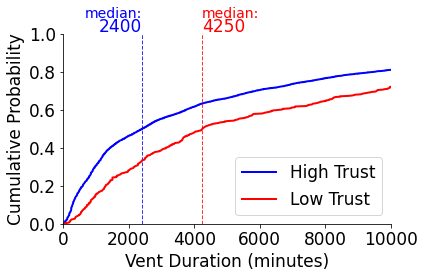

mistrust_autopsy
vaso
	trust:    4189 1740.0
	mistrust: 421 2340.0
	p-value: 7.01864628380746e-05


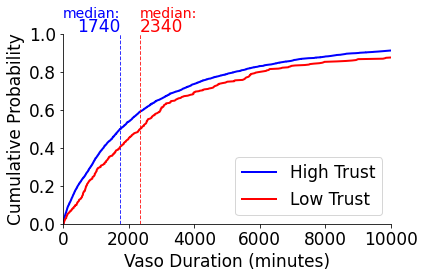

100%|██████████| 2/2 [00:00<00:00, 584.41it/s]


vent 35 43 1673 1673 1674
vaso 34 42 1536 1537 1537


100%|██████████| 2/2 [00:00<00:00, 345.22it/s]

vent
	 low
		 High Trust 1519
		 Low Trust 168
	 medium
		 High Trust 1641
		 Low Trust 178
	 high
		 High Trust 1376
		 Low Trust 138
vaso
	 low
		 High Trust 1440
		 Low Trust 114
	 medium
		 High Trust 1438
		 Low Trust 156
	 high
		 High Trust 1311
		 Low Trust 151
vent
	 vent low
		 High Trust 1519
		 Low Trust 168
vent low
	trust:    1519 1340.0
	mistrust: 168 5328.0
	p-value: 3.124440674979875e-16
	 vent medium
		 High Trust 1641
		 Low Trust 178
vent medium
	trust:    1641 2595.0
	mistrust: 178 3645.0
	p-value: 0.0009033163346815064
	 vent high
		 High Trust 1376
		 Low Trust 138
vent high
	trust:    1376 3440.0
	mistrust: 138 4771.0
	p-value: 0.0025109862275810198


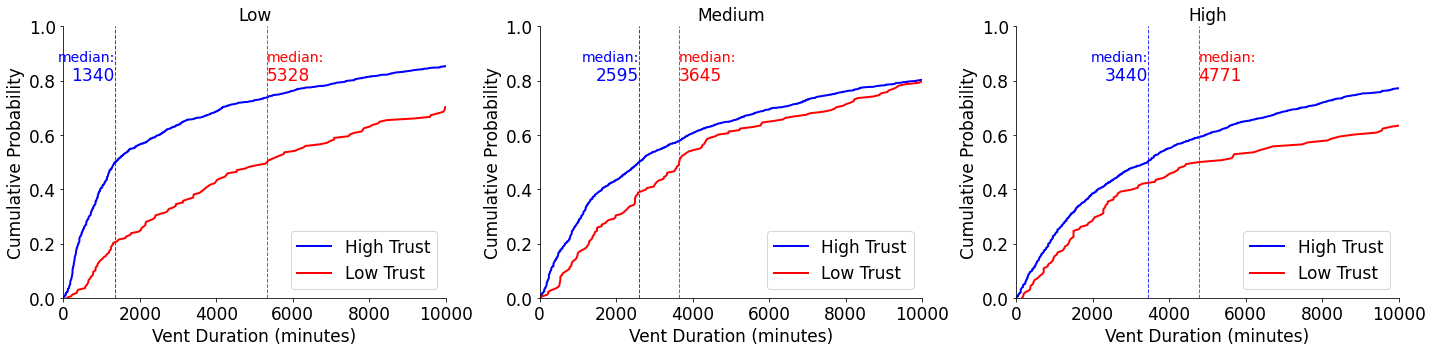

vaso
	 vaso low
		 High Trust 1440
		 Low Trust 114
vaso low
	trust:    1440 1327.0
	mistrust: 114 2220.0
	p-value: 0.0018681957937268753
	 vaso medium
		 High Trust 1438
		 Low Trust 156
vaso medium
	trust:    1438 1695.0
	mistrust: 156 2460.0
	p-value: 0.009564237678756266
	 vaso high
		 High Trust 1311
		 Low Trust 151
vaso high
	trust:    1311 2298.0
	mistrust: 151 2310.0
	p-value: 0.24877717341743955


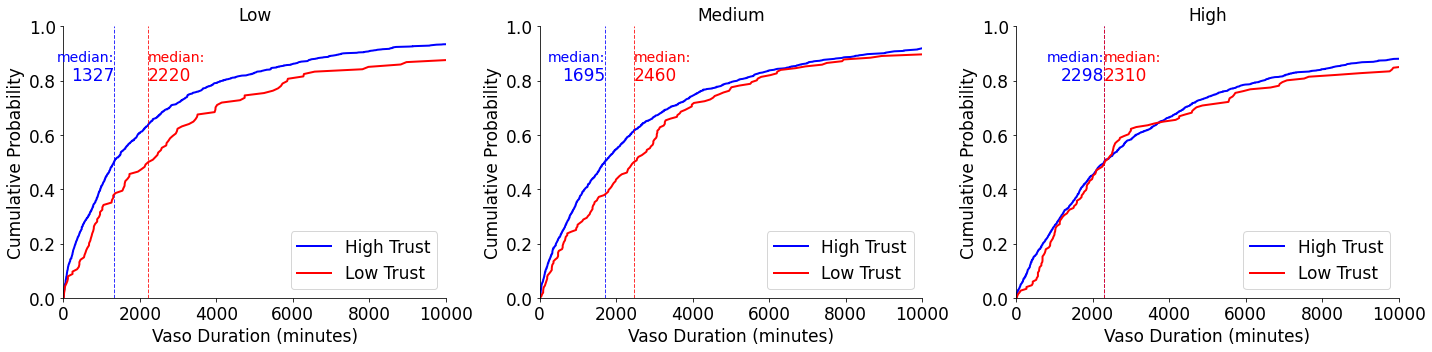

In [21]:
# Mistrust scores
print(time.strftime("%Y-%m-%d %H:%M:%s"))
import pickle as pickle

#mistrust_str = 'mistrust_noncompliant'
mistrust_str = 'mistrust_autopsy'
#mistrust_str = 'neg_sentiment'

with open('../data/%s.pkl' % mistrust_str, 'rb') as f:
    trust_scores = pickle.load(f)
print(time.strftime("%Y-%m-%d %H:%M:%s"))


%matplotlib inline

import pylab as pl
import numpy as np
from scipy.stats import mannwhitneyu


# Put each treatment into the dictionary
T = {}
for vaso,vaso_quantity in list(vaso_quantities.items()): 
    # Get size of b/w cohorts
    vaso_white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(trust_scores.keys()) & set(vaso_quantity.keys())
    vaso_black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(trust_scores.keys()) & set(vaso_quantity.keys())

    # Stratify into high/low trust
    vaso_cohort = (vaso_white_ids | vaso_black_ids)  & set(vaso_quantity.keys())
    vaso_cohort_ids = sorted([(hadm_id,trust_scores[hadm_id]) for hadm_id in vaso_cohort], key=lambda t:t[1])
    vaso_trust_ids    = [hadm_id for hadm_id,score in vaso_cohort_ids[:len(vaso_white_ids) ]]
    vaso_mistrust_ids = [hadm_id for hadm_id,score in vaso_cohort_ids[ len(vaso_white_ids):]]

    trust_eol_vaso    = {hadm_id:vaso_quantity[hadm_id] for hadm_id in vaso_trust_ids    if hadm_id in vaso_quantity}
    mistrust_eol_vaso = {hadm_id:vaso_quantity[hadm_id] for hadm_id in vaso_mistrust_ids if hadm_id in vaso_quantity}
    T[vaso] = {'Low Trust':mistrust_eol_vaso, 'High Trust':trust_eol_vaso}

# Get size of b/w cohorts
vent_white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(trust_scores.keys()) & set(vent_quantity.keys())
vent_black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(trust_scores.keys()) & set(vent_quantity.keys())

# Stratify into high/low trust
vent_cohort = (vent_white_ids | vent_black_ids)
vent_cohort_ids = sorted([(hadm_id,trust_scores[hadm_id]) for hadm_id in vent_cohort], key=lambda t:t[1])
vent_trust_ids    = [hadm_id for hadm_id,score in vent_cohort_ids[:len(vent_white_ids) ]]
vent_mistrust_ids = [hadm_id for hadm_id,score in vent_cohort_ids[ len(vent_white_ids):]]

trust_eol_vent    = {hadm_id:vent_quantity[hadm_id] for hadm_id in vent_trust_ids   }
mistrust_eol_vent = {hadm_id:vent_quantity[hadm_id] for hadm_id in vent_mistrust_ids}
T['vent'] =  {'Low Trust':mistrust_eol_vent, 'High Trust':trust_eol_vent}



import pylab as plt

def list_median(vals):
    svals = sorted(vals)
    return svals[old_div(len(svals),2)]

def captialize(t):
    return ' '.join([w.capitalize() for w in t.split()])

colors = ['#0000FF', '#FF0000']
for treatment in sorted(T.keys(), reverse=True):
    i = 0
    
    fig = pl.figure(treatment)

    t_median = list_median(list(T[treatment]['High Trust'].values()))
    m_median = list_median(list(T[treatment][ 'Low Trust'].values()))
    larger_median = min(t_median, m_median)
        
    for demographic in ['High Trust', 'Low Trust']:
        vals = list(T[treatment][demographic].values())
        #print(len(vals))
        #print (np.sort(vals)[int(len(vals)/2)])
        plt.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[i], label = demographic, lw=2)
        plt.xlim((0,10000))
        plt.ylim((0,1.0))

        median = np.sort(vals)[int(old_div(len(vals),2))]
        plt.axvline(x=median, linestyle="--", lw=1, color=colors[i], alpha=0.8) 
        if median == larger_median:
            p = 10
            h = 'right'
        else:
            p = -10
            h = 'left'
        #h = 'center'
        plt.text(x=median+p, y=1.085, horizontalalignment=h, s="median:", fontsize=14, color=colors[i])
        plt.text(x=median+p, y=1.01 , horizontalalignment=h, s=str(int(median)), fontsize=17, color=colors[i])

        i += 1

    ax = plt.subplot(111)    
    ax.spines["top"].set_visible(False)    
    #ax.spines["bottom"].set_visible(False)    
    ax.spines["right"].set_visible(False)    
    #ax.spines["left"].set_visible(False)    
    plt.yticks(fontsize=17)    
    plt.xticks(fontsize=17) 

    plt.legend(loc=4, fontsize=17)
    plt.ylabel("Cumulative Probability", fontsize=17)
    plt.xlabel("%s Duration (minutes)" % captialize(treatment), fontsize=17)

    plt.tight_layout()
    plt.savefig('../images/chapter5/%s_mimic_%s.png' % (mistrust_str,treatment))

    p1 = list(T[treatment]['High Trust'].values())
    p2 = list(T[treatment][ 'Low Trust'].values())
    w = mannwhitneyu(p1, p2)
    print(mistrust_str)
    print(treatment)
    print('\ttrust:   ', len(p1), t_median)
    print('\tmistrust:', len(p2), m_median)
    print('\tp-value:', w.pvalue)
    
    plt.show()
    
    
    
treatment_severity_populations = {treatment:[] for treatment in sorted(T.keys(), reverse=True)}
for treatment,race_cohorts in tqdm.tqdm(sorted(T.items(), reverse=True)):
    for race,race_cohort in list(race_cohorts.items()):
        for hadm_id,amount in list(race_cohort.items()):
            severity = severities[hadm_id]
            treatment_severity_populations[treatment].append(severity)

treatment_severity_thresholds = {}
for treatment,scores in sorted(treatment_severity_populations.items(), reverse=True):
    vals = sorted(scores)
    n = len(vals)
    print(treatment, vals[old_div(n,3)], vals[old_div(2*n,3)], len(vals[:old_div(n,3)]), len(vals[old_div(n,3):old_div(2*n,3)]), len(vals[old_div(2*n,3):]))
    treatment_severity_thresholds[treatment] = vals[old_div(n,3)], vals[old_div(2*n,3)]
    
    
    
    
import tqdm

# partition by treatment
T_risk = defaultdict(lambda:defaultdict(lambda:defaultdict(list)))
for treatment,race_cohorts in tqdm.tqdm(sorted(T.items(), reverse=True)):
    for race,race_cohort in list(race_cohorts.items()):
        for hadm_id,amount in list(race_cohort.items()):
            # acuity bin
            severity = severities[hadm_id]
            if severities[hadm_id] <= treatment_severity_thresholds[treatment][0]:
                acuity = 'low'
            elif severities[hadm_id] <= treatment_severity_thresholds[treatment][1]:
                acuity = 'medium'
            else:
                acuity = 'high'

            T_risk[treatment][acuity][race].append(amount)

for treatment,cohorts in sorted(T_risk.items(), reverse=True):
    print(treatment)
    for severity in ['low', 'medium', 'high']:
        print('\t', severity)
        cohort = cohorts[severity]
        for race,ids in sorted(cohort.items()):
            print('\t\t', race, len(ids))
            
            

for treatment in sorted(T_risk.keys(), reverse=True):
    #if 'vaso' not in treatment: continue
    print(treatment)
    fig = pl.figure(treatment, (20,5))

    for i,severity in enumerate(['low','medium','high']):
        #fig = pl.figure('-'.join([treatment,severity]))
        ind = 131 + i
        ax = fig.add_subplot(ind)
                
        print('\t', treatment, severity)

        t_median = list_median(T_risk[treatment][severity]['High Trust'])
        m_median = list_median(T_risk[treatment][severity][ 'Low Trust'])
        larger_median = min(t_median, m_median)
        
        for j,demographic in enumerate(['High Trust', 'Low Trust']):
            vals = list(T_risk[treatment][severity][demographic])
            #print(len(vals))
            #print (np.sort(vals)[int(len(vals)/2)])
            ax.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[j], label = demographic, lw=2)
            pl.xlim((0,10000))
            pl.ylim((0,1.0))

            print('\t\t', demographic, len(vals))
            median = np.sort(vals)[int(old_div(len(vals),2))]
            ax.axvline(x=median, linestyle="--", lw=1, color=colors[j], alpha=0.8) 
            if median == larger_median:
                p = 10
                h = 'right'
            else:
                p = -10
                h = 'left'
            #h = 'center'
            ax.text(x=median+p, y=0.87, horizontalalignment=h, s="median:", fontsize=14, color=colors[j])
            ax.text(x=median+p, y=0.8 , horizontalalignment=h, s=str(int(median)), fontsize=17, color=colors[j])

        #ax = pl.subplot(111)    
        ax.spines["top"].set_visible(False)    
        #ax.spines["bottom"].set_visible(False)    
        ax.spines["right"].set_visible(False)    
        #ax.spines["left"].set_visible(False)    
        pl.yticks(fontsize=17)    
        pl.xticks(fontsize=17) 

        pl.title(captialize(severity), fontsize=17)
        pl.legend(loc=4, fontsize=17)
        pl.ylabel("Cumulative Probability", fontsize=17)
        pl.xlabel("%s Duration (minutes)" % captialize(treatment), fontsize=17)

        pl.tight_layout()

        p1 = list(T_risk[treatment][severity]['High Trust'])
        p2 = list(T_risk[treatment][severity][ 'Low Trust'])
        w = mannwhitneyu(p1, p2)
        print(treatment, severity)
        print('\ttrust:   ', len(p1), t_median)
        print('\tmistrust:', len(p2), m_median)
        print('\tp-value:', w.pvalue)
    pl.savefig('../images/chapter5/%s_mimic_%s_severity.png' % (mistrust_str,treatment))
    pl.show()
    #break
    #exit()

2025-12-02 20:51:1764708691
2025-12-02 20:51:1764708691
neg_sentiment
vent
	trust:    4364 2490.0
	mistrust: 469 3305.0
	p-value: 7.738417046674618e-05


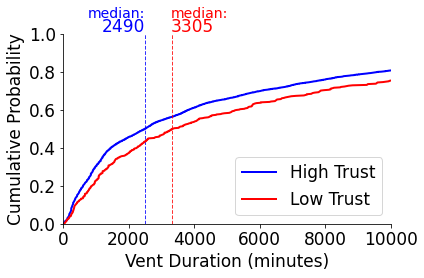

neg_sentiment
vaso
	trust:    4036 1767.0
	mistrust: 407 2087.0
	p-value: 0.0010648409699228138


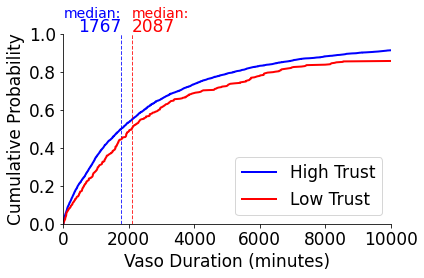

100%|██████████| 2/2 [00:00<00:00, 560.36it/s]


vent 35 43 1611 1611 1611
vaso 34 42 1481 1481 1481


100%|██████████| 2/2 [00:00<00:00, 346.91it/s]

vent
	 low
		 High Trust 1489
		 Low Trust 150
	 medium
		 High Trust 1590
		 Low Trust 166
	 high
		 High Trust 1285
		 Low Trust 153
vaso
	 low
		 High Trust 1386
		 Low Trust 132
	 medium
		 High Trust 1407
		 Low Trust 132
	 high
		 High Trust 1243
		 Low Trust 143
vent
	 vent low
		 High Trust 1489
		 Low Trust 150
vent low
	trust:    1489 1437.0
	mistrust: 150 3075.0
	p-value: 0.004171162601173349
	 vent medium
		 High Trust 1590
		 Low Trust 166
vent medium
	trust:    1590 2600.0
	mistrust: 166 3705.0
	p-value: 0.001218551842341316
	 vent high
		 High Trust 1285
		 Low Trust 153
vent high
	trust:    1285 3600.0
	mistrust: 153 3255.0
	p-value: 0.36015432508182943


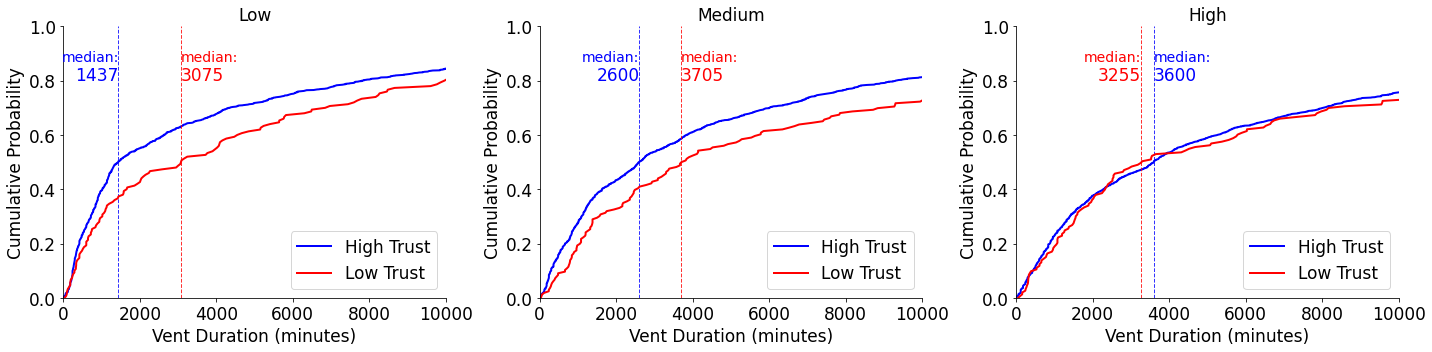

vaso
	 vaso low
		 High Trust 1386
		 Low Trust 132
vaso low
	trust:    1386 1295.0
	mistrust: 132 1681.0
	p-value: 0.08615371163078722
	 vaso medium
		 High Trust 1407
		 Low Trust 132
vaso medium
	trust:    1407 1740.0
	mistrust: 132 2205.0
	p-value: 0.0021089060215160192
	 vaso high
		 High Trust 1243
		 Low Trust 143
vaso high
	trust:    1243 2340.0
	mistrust: 143 2385.0
	p-value: 0.17629125432329745


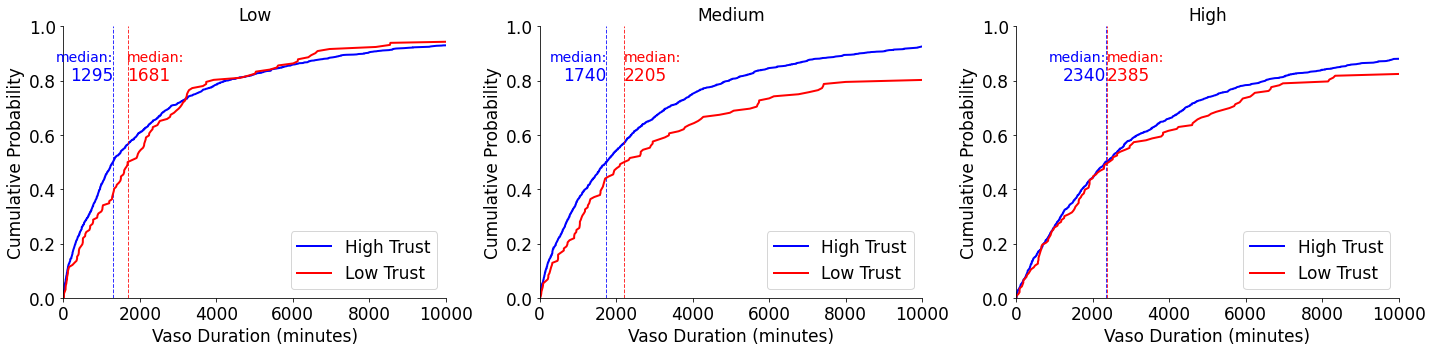

In [22]:
# Mistrust scores
print(time.strftime("%Y-%m-%d %H:%M:%s"))
import pickle as pickle

#mistrust_str = 'mistrust_noncompliant'
#mistrust_str = 'mistrust_autopsy'
mistrust_str = 'neg_sentiment'

with open('../data/%s.pkl' % mistrust_str, 'rb') as f:
    trust_scores = pickle.load(f)
print(time.strftime("%Y-%m-%d %H:%M:%s"))


%matplotlib inline

import pylab as pl
import numpy as np
from scipy.stats import mannwhitneyu


# Put each treatment into the dictionary
T = {}
for vaso,vaso_quantity in sorted(vaso_quantities.items(), reverse=True): 
    # Get size of b/w cohorts
    vaso_white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(trust_scores.keys()) & set(vaso_quantity.keys())
    vaso_black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(trust_scores.keys()) & set(vaso_quantity.keys())

    # Stratify into high/low trust
    vaso_cohort = (vaso_white_ids | vaso_black_ids)  & set(vaso_quantity.keys())
    vaso_cohort_ids = sorted([(hadm_id,trust_scores[hadm_id]) for hadm_id in vaso_cohort], key=lambda t:t[1])
    vaso_trust_ids    = [hadm_id for hadm_id,score in vaso_cohort_ids[:len(vaso_white_ids) ]]
    vaso_mistrust_ids = [hadm_id for hadm_id,score in vaso_cohort_ids[ len(vaso_white_ids):]]

    trust_eol_vaso    = {hadm_id:vaso_quantity[hadm_id] for hadm_id in vaso_trust_ids    if hadm_id in vaso_quantity}
    mistrust_eol_vaso = {hadm_id:vaso_quantity[hadm_id] for hadm_id in vaso_mistrust_ids if hadm_id in vaso_quantity}
    T[vaso] = {'Low Trust':mistrust_eol_vaso, 'High Trust':trust_eol_vaso}

# Get size of b/w cohorts
vent_white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(trust_scores.keys()) & set(vent_quantity.keys())
vent_black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(trust_scores.keys()) & set(vent_quantity.keys())

# Stratify into high/low trust
vent_cohort = (vent_white_ids | vent_black_ids)
vent_cohort_ids = sorted([(hadm_id,trust_scores[hadm_id]) for hadm_id in vent_cohort], key=lambda t:t[1])
vent_trust_ids    = [hadm_id for hadm_id,score in vent_cohort_ids[:len(vent_white_ids) ]]
vent_mistrust_ids = [hadm_id for hadm_id,score in vent_cohort_ids[ len(vent_white_ids):]]

trust_eol_vent    = {hadm_id:vent_quantity[hadm_id] for hadm_id in vent_trust_ids   }
mistrust_eol_vent = {hadm_id:vent_quantity[hadm_id] for hadm_id in vent_mistrust_ids}
T['vent'] =  {'Low Trust':mistrust_eol_vent, 'High Trust':trust_eol_vent}



import pylab as plt

def list_median(vals):
    svals = sorted(vals)
    return svals[old_div(len(svals),2)]

def captialize(t):
    return ' '.join([w.capitalize() for w in t.split()])

colors = ['#0000FF', '#FF0000']
for treatment in sorted(T.keys(), reverse=True):
    i = 0
    
    fig = pl.figure(treatment)

    t_median = list_median(list(T[treatment]['High Trust'].values()))
    m_median = list_median(list(T[treatment][ 'Low Trust'].values()))
    larger_median = min(t_median, m_median)
        
    for demographic in ['High Trust', 'Low Trust']:
        vals = list(T[treatment][demographic].values())
        #print(len(vals))
        #print (np.sort(vals)[int(len(vals)/2)])
        plt.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[i], label = demographic, lw=2)
        plt.xlim((0,10000))
        plt.ylim((0,1.0))

        median = np.sort(vals)[int(old_div(len(vals),2))]
        plt.axvline(x=median, linestyle="--", lw=1, color=colors[i], alpha=0.8) 
        if median == larger_median:
            p = 10
            h = 'right'
        else:
            p = -10
            h = 'left'
        #h = 'center'
        plt.text(x=median+p, y=1.085, horizontalalignment=h, s="median:", fontsize=14, color=colors[i])
        plt.text(x=median+p, y=1.01 , horizontalalignment=h, s=str(int(median)), fontsize=17, color=colors[i])

        i += 1

    ax = plt.subplot(111)    
    ax.spines["top"].set_visible(False)    
    #ax.spines["bottom"].set_visible(False)    
    ax.spines["right"].set_visible(False)    
    #ax.spines["left"].set_visible(False)    
    plt.yticks(fontsize=17)    
    plt.xticks(fontsize=17) 

    plt.legend(loc=4, fontsize=17)
    plt.ylabel("Cumulative Probability", fontsize=17)
    plt.xlabel("%s Duration (minutes)" % captialize(treatment), fontsize=17)

    plt.tight_layout()
    plt.savefig('../images/chapter5/%s_mimic_%s.png' % (mistrust_str,treatment))

    p1 = list(T[treatment]['High Trust'].values())
    p2 = list(T[treatment][ 'Low Trust'].values())
    w = mannwhitneyu(p1, p2)
    print(mistrust_str)
    print(treatment)
    print('\ttrust:   ', len(p1), t_median)
    print('\tmistrust:', len(p2), m_median)
    print('\tp-value:', w.pvalue)
    
    plt.show()
    
    
    
treatment_severity_populations = {treatment:[] for treatment in list(T.keys())}
for treatment,race_cohorts in tqdm.tqdm(sorted(T.items(), reverse=True)):
    for race,race_cohort in list(race_cohorts.items()):
        for hadm_id,amount in list(race_cohort.items()):
            severity = severities[hadm_id]
            treatment_severity_populations[treatment].append(severity)

treatment_severity_thresholds = {}
for treatment,scores in sorted(treatment_severity_populations.items(), reverse=True):
    vals = sorted(scores)
    n = len(vals)
    print(treatment, vals[old_div(n,3)], vals[old_div(2*n,3)], len(vals[:old_div(n,3)]), len(vals[old_div(n,3):old_div(2*n,3)]), len(vals[old_div(2*n,3):]))
    treatment_severity_thresholds[treatment] = vals[old_div(n,3)], vals[old_div(2*n,3)]
    
    
    
    
import tqdm

# partition by treatment
T_risk = defaultdict(lambda:defaultdict(lambda:defaultdict(list)))
for treatment,race_cohorts in tqdm.tqdm(sorted(T.items(), reverse=True)):
    for race,race_cohort in list(race_cohorts.items()):
        for hadm_id,amount in list(race_cohort.items()):
            # acuity bin
            severity = severities[hadm_id]
            if severities[hadm_id] <= treatment_severity_thresholds[treatment][0]:
                acuity = 'low'
            elif severities[hadm_id] <= treatment_severity_thresholds[treatment][1]:
                acuity = 'medium'
            else:
                acuity = 'high'

            T_risk[treatment][acuity][race].append(amount)

for treatment,cohorts in sorted(T_risk.items(), reverse=True):
    print(treatment)
    for severity in ['low', 'medium', 'high']:
        print('\t', severity)
        cohort = cohorts[severity]
        for race,ids in sorted(cohort.items()):
            print('\t\t', race, len(ids))
            
            

for treatment in sorted(T_risk.keys(), reverse=True):
    #if 'vaso' not in treatment: continue
    print(treatment)
    fig = pl.figure(treatment, (20,5))

    for i,severity in enumerate(['low','medium','high']):
        #fig = pl.figure('-'.join([treatment,severity]))
        ind = 131 + i
        ax = fig.add_subplot(ind)
                
        print('\t', treatment, severity)

        t_median = list_median(T_risk[treatment][severity]['High Trust'])
        m_median = list_median(T_risk[treatment][severity][ 'Low Trust'])
        larger_median = min(t_median, m_median)
        
        for j,demographic in enumerate(['High Trust', 'Low Trust']):
            vals = list(T_risk[treatment][severity][demographic])
            #print(len(vals))
            #print (np.sort(vals)[int(len(vals)/2)])
            ax.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[j], label = demographic, lw=2)
            pl.xlim((0,10000))
            pl.ylim((0,1.0))

            print('\t\t', demographic, len(vals))
            median = np.sort(vals)[int(old_div(len(vals),2))]
            ax.axvline(x=median, linestyle="--", lw=1, color=colors[j], alpha=0.8) 
            if median == larger_median:
                p = 10
                h = 'right'
            else:
                p = -10
                h = 'left'
            #h = 'center'
            ax.text(x=median+p, y=0.87, horizontalalignment=h, s="median:", fontsize=14, color=colors[j])
            ax.text(x=median+p, y=0.8 , horizontalalignment=h, s=str(int(median)), fontsize=17, color=colors[j])

        #ax = pl.subplot(111)    
        ax.spines["top"].set_visible(False)    
        #ax.spines["bottom"].set_visible(False)    
        ax.spines["right"].set_visible(False)    
        #ax.spines["left"].set_visible(False)    
        pl.yticks(fontsize=17)    
        pl.xticks(fontsize=17) 

        pl.title(captialize(severity), fontsize=17)
        pl.legend(loc=4, fontsize=17)
        pl.ylabel("Cumulative Probability", fontsize=17)
        pl.xlabel("%s Duration (minutes)" % captialize(treatment), fontsize=17)

        pl.tight_layout()

        p1 = list(T_risk[treatment][severity]['High Trust'])
        p2 = list(T_risk[treatment][severity][ 'Low Trust'])
        w = mannwhitneyu(p1, p2)
        print(treatment, severity)
        print('\ttrust:   ', len(p1), t_median)
        print('\tmistrust:', len(p2), m_median)
        print('\tp-value:', w.pvalue)
    pl.savefig('../images/chapter5/%s_mimic_%s_severity.png' % (mistrust_str,treatment))
    pl.show()
    #break
    #exit()